
Run-level TMT error results:
Pattern  Run  GroundTruth  SHA_Error  SHA_Relative_Error_Pct  PMM_Error  PMM_Relative_Error_Pct  RF_Error  RF_Relative_Error_Pct
      A    1    297951770     -17635               -0.005919      -7483               -0.002511    -82061              -0.027542
      A    2    297960560     -13595               -0.004563      -3214               -0.001079    -82286              -0.027616
      A    3    297881890     -11880               -0.003988       4708                0.001580    -73932              -0.024819
      A    4    297870725     -14915               -0.005007       1555                0.000522    -74871              -0.025135
      A    5    297964690     -12385               -0.004157       7030                0.002359    -74111              -0.024872
      A    6    297958955     -12140               -0.004074      -4158               -0.001395    -84304              -0.028294
      A    7    297895375     -15320               -0.005143     -1

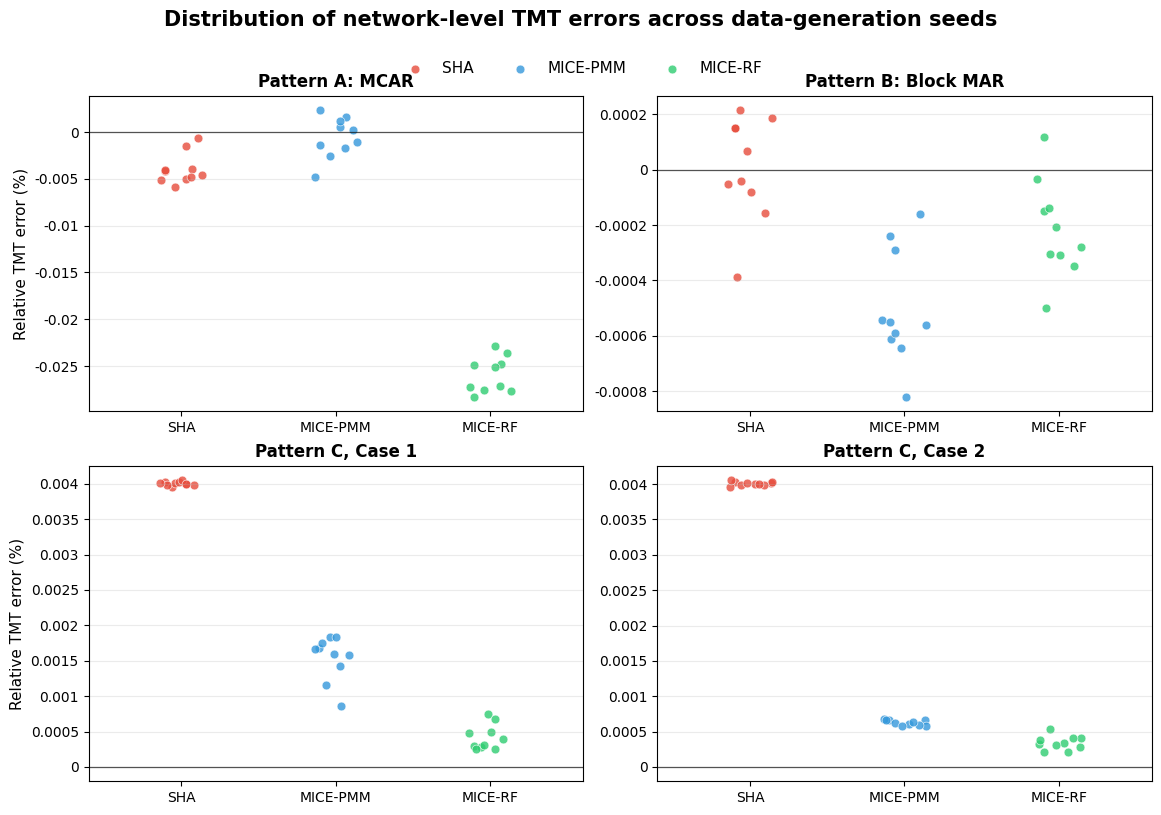

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from pathlib import Path
import numpy as np


# 1. Folder containing all master CSV files
DATA_DIR = Path("/home/raheemr/Desktop/macroanalysis results/")

# 2. File configuration
FILES = {
    "A": {
        "title": "Pattern A: MCAR",
        "sha_tmt": "sha_MASTER_tmt_results_patternA.csv",
        "pmm_rubin": "patternA_MICE_PMM_MASTER_Rubin.csv",
        "rf_rubin": "patternA_MICE_RF_MASTER_Rubin.csv",
    },
    "B": {
        "title": "Pattern B: Block MAR",
        "sha_tmt": "sha_MASTER_tmt_results_patternB.csv",
        "pmm_rubin": "patternB_MICE_PMM_MASTER_Rubin_TMT.csv",
        "rf_rubin": "patternB_MICE_RF_MASTER_Rubin_TMT.csv",
    },
    "C1": {
        "title": "Pattern C, Case 1",
        "sha_tmt": "sha_MASTER_tmt_results_patternC.csv",
        "pmm_rubin": "patternC_MICE_PMM_MASTER_Rubin_TMT.csv",
        "rf_rubin": "patternC_MICE_RF_MASTER_Rubin_TMT.csv",
    },
    "C2": {
        "title": "Pattern C, Case 2",
        "sha_tmt": "sha_MASTER_tmt_results_patternC3.csv",
        "pmm_rubin": "patternC_MICE_PMM_MASTER_Rubin_TMT3.csv",
        "rf_rubin": "patternC_MICE_RF_MASTER_Rubin_TMT3.csv",
    },
}


# 3. Helper functions
def load_sha_tmt(filepath):
    """
    Extract GroundTruth and SHA TMT estimates for each data-generation run.
    """
    df = pd.read_csv(filepath)

    ground_truth = (df[df["Dataset"].str.lower() == "groundtruth"][["Dataset_Run", "Total_Miles_Travelled"]]
        .rename(columns={"Total_Miles_Travelled": "GroundTruth"}))

    sha_estimate = (df[df["Dataset"].str.contains("SHA", case=False, na=False)][["Dataset_Run", "Total_Miles_Travelled"]]
        .rename(columns={"Total_Miles_Travelled": "SHA"}))

    return ground_truth.merge(sha_estimate, on="Dataset_Run")


def load_rubin_qbar(filepath, method_name):
    """
    Extract Rubin-pooled TMT estimate Q_bar for one MICE method.
    """
    df = pd.read_csv(filepath)

    return (df[["Dataset_Run", "Q_bar"]].rename(columns={"Q_bar": method_name}))


# 4. Build one combined run-level TMT error dataset


all_results = []

for pattern, config in FILES.items():

    sha_df = load_sha_tmt(DATA_DIR / config["sha_tmt"])
    pmm_df = load_rubin_qbar(DATA_DIR / config["pmm_rubin"], "MICE_PMM")
    rf_df = load_rubin_qbar(DATA_DIR / config["rf_rubin"], "MICE_RF")

    result = (sha_df.merge(pmm_df, on="Dataset_Run").merge(rf_df, on="Dataset_Run"))

    result["Pattern"] = pattern
    result["Pattern_Title"] = config["title"]

    # Signed TMT errors
    result["SHA_Error"] = result["SHA"] - result["GroundTruth"]
    result["PMM_Error"] = result["MICE_PMM"] - result["GroundTruth"]
    result["RF_Error"] = result["MICE_RF"] - result["GroundTruth"]

    # Relative TMT errors as percentages
    result["SHA_Relative_Error_Pct"] = ( 100 * result["SHA_Error"] / result["GroundTruth"])

    result["PMM_Relative_Error_Pct"] = (100 * result["PMM_Error"] / result["GroundTruth"])

    result["RF_Relative_Error_Pct"] = (100 * result["RF_Error"] / result["GroundTruth"] )

    result = result.rename(columns={"Dataset_Run": "Run"})
    all_results.append(result)

tmt_errors = pd.concat(all_results, ignore_index=True)

# Save the calculated values used in the figure
tmt_errors.to_csv("tmt_seed_errors.csv", index=False)

print("\nRun-level TMT error results:")
print(
    tmt_errors[
        [
            "Pattern",
            "Run",
            "GroundTruth",
            "SHA_Error",
            "SHA_Relative_Error_Pct",
            "PMM_Error",
            "PMM_Relative_Error_Pct",
            "RF_Error",
            "RF_Relative_Error_Pct",
        ]
    ].to_string(index=False)
)


# 5. Summary table: mean absolute relative TMT error


summary_rows = []

for pattern, group in tmt_errors.groupby("Pattern"):

    summary_rows.append(
        {
            "Pattern": pattern,
            "SHA_MARE_Pct": group["SHA_Relative_Error_Pct"].abs().mean(),
            "PMM_MARE_Pct": group["PMM_Relative_Error_Pct"].abs().mean(),
            "RF_MARE_Pct": group["RF_Relative_Error_Pct"].abs().mean(),
        }
    )

tmt_summary = pd.DataFrame(summary_rows)

print("\nMean absolute relative TMT error (%):")
print(tmt_summary.round(6).to_string(index=False))

tmt_summary.to_csv("tmt_seed_error_summary.csv", index=False)


# 6. Plot categorical scatter plots for TMT errors


pattern_order = ["A", "B", "C1", "C2"]

method_config = {
    "SHA": {
        "column": "SHA_Relative_Error_Pct",
        "label": "SHA",
        "color": "#e74c3c",
        "x_pos": 1
    },
    "PMM": {
        "column": "PMM_Relative_Error_Pct",
        "label": "MICE-PMM",
        "color": "#3498db",
        "x_pos": 2
    },
    "RF": {
        "column": "RF_Relative_Error_Pct",
        "label": "MICE-RF",
        "color": "#2ecc71",
        "x_pos": 3
    },
}

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(11.5, 7.4),
    constrained_layout=True
)

# Set a random seed just for the visual jitter so the plot looks the same every time
np.random.seed(42)

for ax, pattern in zip(axes.flat, pattern_order):
    
    plot_data = tmt_errors[tmt_errors["Pattern"] == pattern]
    
    # Generate a small amount of horizontal jitter for the 10 points
    # so overlapping data points don't hide each other
    jitter = np.random.uniform(-0.15, 0.15, size=len(plot_data))

    for method, settings in method_config.items():
        
        x_positions = np.full(len(plot_data), settings["x_pos"]) + jitter
        y_values = plot_data[settings["column"]]
        
        ax.scatter(
            x_positions,
            y_values,
            color=settings["color"],
            label=settings["label"],
            alpha=0.8,
            s=40,          # Size of the scatter points
            edgecolors='w', # White border around points for clarity
            linewidth=0.5
        )

    # Add the zero-error baseline
    ax.axhline(0, color="black", linewidth=0.9, alpha=0.65)

    ax.set_title(
        FILES[pattern]["title"],
        fontsize=12,
        fontweight="bold"
    )

    # Format the X-axis to show categorical methods
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(["SHA", "MICE-PMM", "MICE-RF"], fontsize=10)
    ax.set_xlim(0.4, 3.6) # Add padding to the left and right of the plot
    
    ax.grid(axis="y", alpha=0.25)

    # Use panel-specific y-axis labels because error scales differ by pattern
    ax.yaxis.set_major_formatter(
        FuncFormatter(lambda value, position: f"{value:.3g}")
    )

axes[0, 0].set_ylabel("Relative TMT error (%)", fontsize=11)
axes[1, 0].set_ylabel("Relative TMT error (%)", fontsize=11)

# Extract legend handles from the first axis to avoid duplicates
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, 1.03),
    fontsize=11
)

fig.suptitle(
    "Distribution of network-level TMT errors across data-generation seeds",
    fontsize=15,
    fontweight="bold",
    y=1.08,
)


plt.savefig(
    "tmt_seed_scatter_distribution.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()



Run-level TMT error results:
Pattern  Run  GroundTruth  SHA_Error  SHA_Relative_Error_Pct  PMM_Error  PMM_Relative_Error_Pct  RF_Error  RF_Relative_Error_Pct
      A    1    297951770     -17635               -0.005919      -7483               -0.002511    -82061              -0.027542
      A    2    297960560     -13595               -0.004563      -3214               -0.001079    -82286              -0.027616
      A    3    297881890     -11880               -0.003988       4708                0.001580    -73932              -0.024819
      A    4    297870725     -14915               -0.005007       1555                0.000522    -74871              -0.025135
      A    5    297964690     -12385               -0.004157       7030                0.002359    -74111              -0.024872
      A    6    297958955     -12140               -0.004074      -4158               -0.001395    -84304              -0.028294
      A    7    297895375     -15320               -0.005143     -1

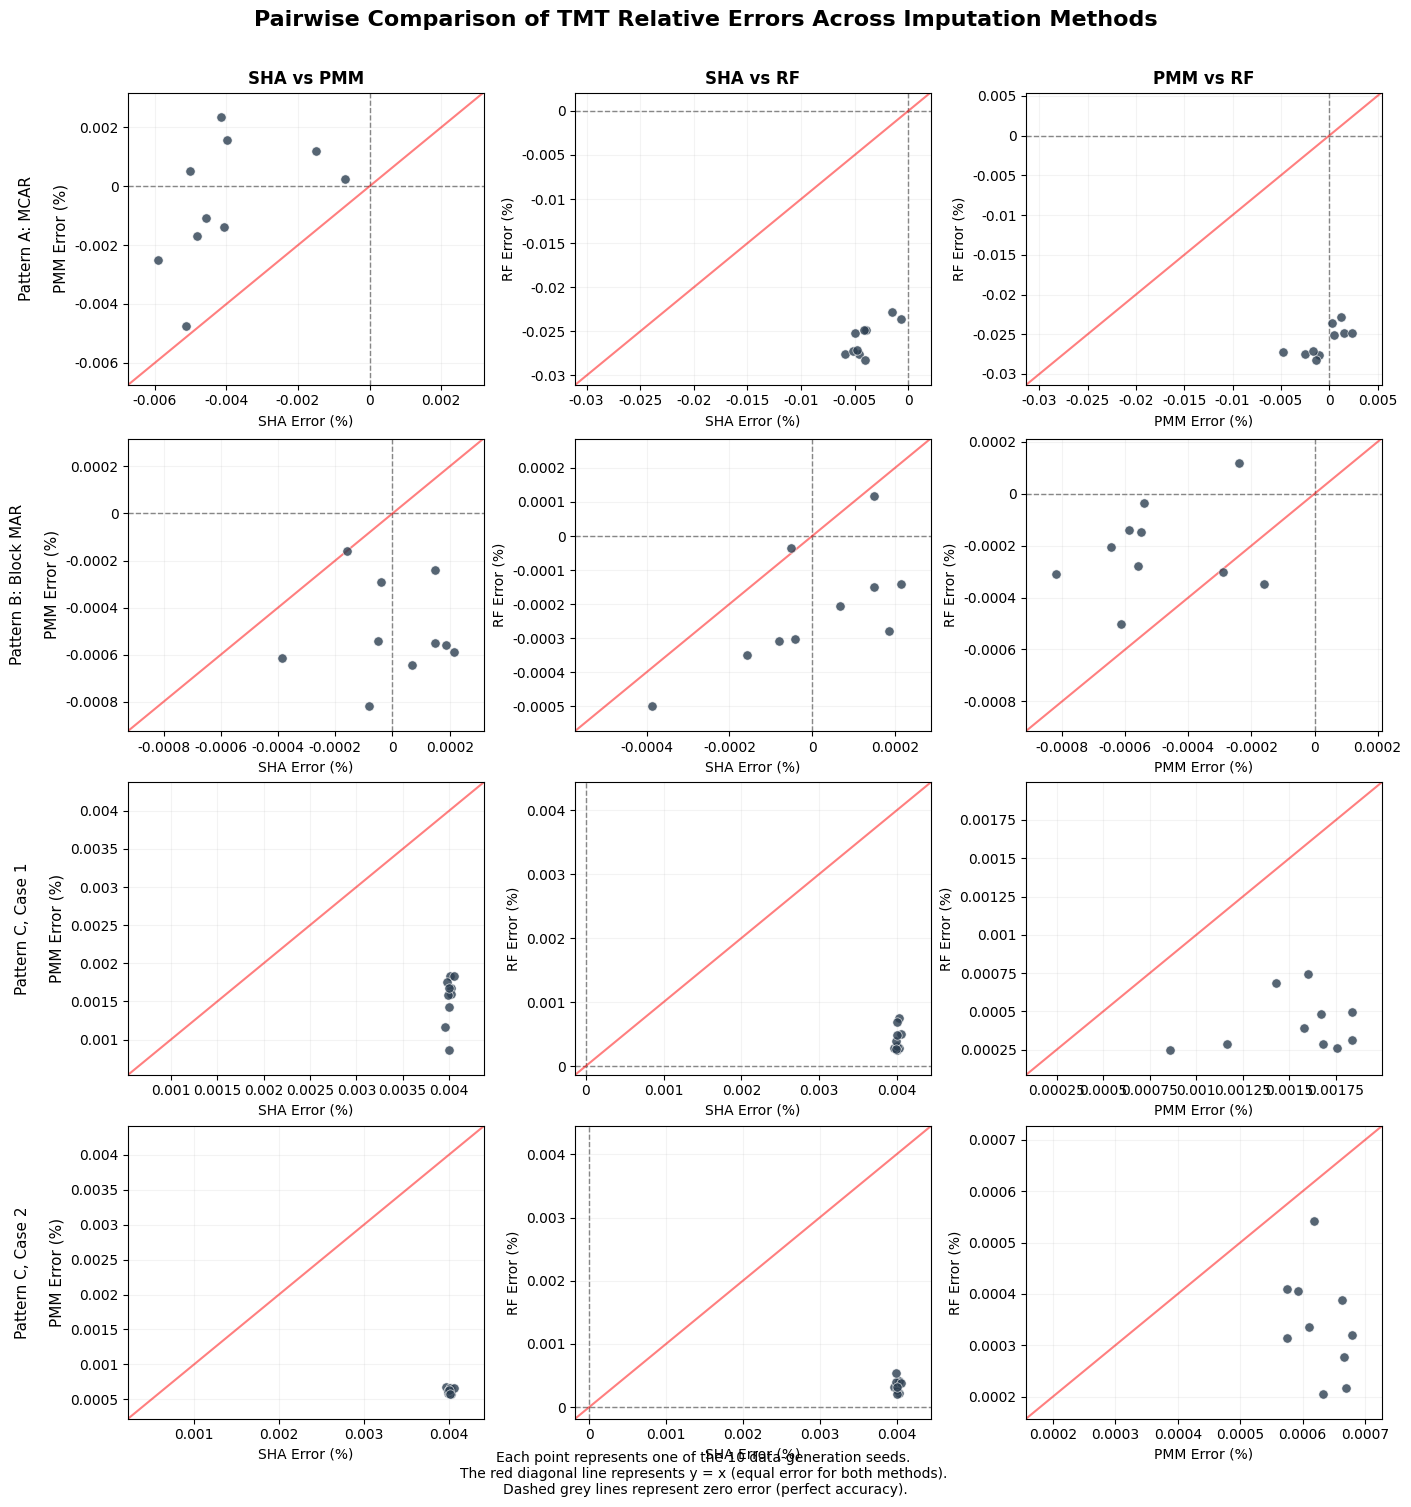

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from pathlib import Path
import  numpy as np
import matplotlib.lines as mlines

# 1. Folder containing all master CSV files
DATA_DIR = Path("/home/raheemr/Desktop/Proj/")

# 2. File configuration
FILES = {
    "A": {
        "title": "Pattern A: MCAR",
        "sha_tmt": "sha_MASTER_tmt_results_patternA.csv",
        "pmm_rubin": "patternA_MICE_PMM_MASTER_Rubin.csv",
        "rf_rubin": "patternA_MICE_RF_MASTER_Rubin.csv",
    },
    "B": {
        "title": "Pattern B: Block MAR",
        "sha_tmt": "sha_MASTER_tmt_results_patternB.csv",
        "pmm_rubin": "patternB_MICE_PMM_MASTER_Rubin_TMT.csv",
        "rf_rubin": "patternB_MICE_RF_MASTER_Rubin_TMT.csv",
    },
    "C1": {
        "title": "Pattern C, Case 1",
        "sha_tmt": "sha_MASTER_tmt_results_patternC.csv",
        "pmm_rubin": "patternC_MICE_PMM_MASTER_Rubin_TMT.csv",
        "rf_rubin": "patternC_MICE_RF_MASTER_Rubin_TMT.csv",
    },
    "C2": {
        "title": "Pattern C, Case 2",
        "sha_tmt": "sha_MASTER_tmt_results_patternC3.csv",
        "pmm_rubin": "patternC_MICE_PMM_MASTER_Rubin_TMT3.csv",
        "rf_rubin": "patternC_MICE_RF_MASTER_Rubin_TMT3.csv",
    },
}


# 3. Helper functions
def load_sha_tmt(filepath):
    """
    Extract GroundTruth and SHA TMT estimates for each data-generation run.
    """
    df = pd.read_csv(filepath)

    ground_truth = (df[df["Dataset"].str.lower() == "groundtruth"][["Dataset_Run", "Total_Miles_Travelled"]]
        .rename(columns={"Total_Miles_Travelled": "GroundTruth"}))

    sha_estimate = (df[df["Dataset"].str.contains("SHA", case=False, na=False)][["Dataset_Run", "Total_Miles_Travelled"]]
        .rename(columns={"Total_Miles_Travelled": "SHA"}))

    return ground_truth.merge(sha_estimate, on="Dataset_Run")


def load_rubin_qbar(filepath, method_name):
    """
    Extract Rubin-pooled TMT estimate Q_bar for one MICE method.
    """
    df = pd.read_csv(filepath)

    return (df[["Dataset_Run", "Q_bar"]].rename(columns={"Q_bar": method_name}))


# 4. Build one combined run-level TMT error dataset


all_results = []

for pattern, config in FILES.items():

    sha_df = load_sha_tmt(DATA_DIR / config["sha_tmt"])
    pmm_df = load_rubin_qbar(DATA_DIR / config["pmm_rubin"], "MICE_PMM")
    rf_df = load_rubin_qbar(DATA_DIR / config["rf_rubin"], "MICE_RF")

    result = (sha_df.merge(pmm_df, on="Dataset_Run").merge(rf_df, on="Dataset_Run"))

    result["Pattern"] = pattern
    result["Pattern_Title"] = config["title"]

    # Signed TMT errors
    result["SHA_Error"] = result["SHA"] - result["GroundTruth"]
    result["PMM_Error"] = result["MICE_PMM"] - result["GroundTruth"]
    result["RF_Error"] = result["MICE_RF"] - result["GroundTruth"]

    # Relative TMT errors as percentages
    result["SHA_Relative_Error_Pct"] = ( 100 * result["SHA_Error"] / result["GroundTruth"])

    result["PMM_Relative_Error_Pct"] = (100 * result["PMM_Error"] / result["GroundTruth"])

    result["RF_Relative_Error_Pct"] = (100 * result["RF_Error"] / result["GroundTruth"] )

    result = result.rename(columns={"Dataset_Run": "Run"})
    all_results.append(result)

tmt_errors = pd.concat(all_results, ignore_index=True)

# Save the calculated values used in the figure
tmt_errors.to_csv("tmt_seed_errors.csv", index=False)

print("\nRun-level TMT error results:")
print(
    tmt_errors[
        [
            "Pattern",
            "Run",
            "GroundTruth",
            "SHA_Error",
            "SHA_Relative_Error_Pct",
            "PMM_Error",
            "PMM_Relative_Error_Pct",
            "RF_Error",
            "RF_Relative_Error_Pct",
        ]
    ].to_string(index=False)
)


# 5. Summary table: mean absolute relative TMT error


summary_rows = []

for pattern, group in tmt_errors.groupby("Pattern"):

    summary_rows.append(
        {
            "Pattern": pattern,
            "SHA_MARE_Pct": group["SHA_Relative_Error_Pct"].abs().mean(),
            "PMM_MARE_Pct": group["PMM_Relative_Error_Pct"].abs().mean(),
            "RF_MARE_Pct": group["RF_Relative_Error_Pct"].abs().mean(),
        }
    )

tmt_summary = pd.DataFrame(summary_rows)

print("\nMean absolute relative TMT error (%):")
print(tmt_summary.round(6).to_string(index=False))

tmt_summary.to_csv("tmt_seed_error_summary.csv", index=False)

# 6. Plot pairwise method-vs-method scatter plots


pattern_order = ["A", "B", "C1", "C2"]

# Define the three pairwise comparisons we want to make
comparisons = [
    {"x": "SHA", "y": "PMM", "x_col": "SHA_Relative_Error_Pct", "y_col": "PMM_Relative_Error_Pct"},
    {"x": "SHA", "y": "RF",  "x_col": "SHA_Relative_Error_Pct", "y_col": "RF_Relative_Error_Pct"},
    {"x": "PMM", "y": "RF",  "x_col": "PMM_Relative_Error_Pct", "y_col": "RF_Relative_Error_Pct"},
]

fig, axes = plt.subplots(
    nrows=4,
    ncols=3,
    figsize=(14, 14),
    constrained_layout=True
)

for row, pattern in enumerate(pattern_order):
    plot_data = tmt_errors[tmt_errors["Pattern"] == pattern]
    
    for col, comp in enumerate(comparisons):
        ax = axes[row, col]
        
        x_vals = plot_data[comp["x_col"]]
        y_vals = plot_data[comp["y_col"]]
        
        # Scatter the 10 runs
        ax.scatter(
            x_vals,
            y_vals,
            color="#2c3e50",
            alpha=0.8,
            s=45,
            edgecolors='w',
            linewidth=0.5,
            zorder=3
        )
        
        # Determine axis limits to make the plot square and fit the y=x line properly
        min_val = min(x_vals.min(), y_vals.min())
        max_val = max(x_vals.max(), y_vals.max())
        
        # Add 10% padding to the limits
        padding = (max_val - min_val) * 0.1
        if padding == 0: padding = 0.001 # Fallback if all values are identical
        
        lim_min = min_val - padding
        lim_max = max_val + padding
        
        ax.set_xlim(lim_min, lim_max)
        ax.set_ylim(lim_min, lim_max)
        
        # Add the zero-error reference lines (horizontal and vertical)
        ax.axhline(0, color="gray", linewidth=1, linestyle="--", zorder=1)
        ax.axvline(0, color="gray", linewidth=1, linestyle="--", zorder=1)
        
        # Add the y=x identity line (45-degree line)
        line = mlines.Line2D([lim_min, lim_max], [lim_min, lim_max], color="red", alpha=0.5, linewidth=1.5, zorder=2)
        ax.add_line(line)
        
        # Formatting
        if row == 0:
            ax.set_title(f'{comp["x"]} vs {comp["y"]}', fontsize=12, fontweight="bold")
            
        if col == 0:
            ax.set_ylabel(f'{FILES[pattern]["title"]}\n\n{comp["y"]} Error (%)', fontsize=11)
        else:
            ax.set_ylabel(f'{comp["y"]} Error (%)', fontsize=10)
            
        ax.set_xlabel(f'{comp["x"]} Error (%)', fontsize=10)
        
        # Format ticks
        ax.xaxis.set_major_formatter(FuncFormatter(lambda value, position: f"{value:.3g}"))
        ax.yaxis.set_major_formatter(FuncFormatter(lambda value, position: f"{value:.3g}"))
        ax.grid(True, alpha=0.15)

fig.suptitle(
    "Pairwise Comparison of TMT Relative Errors Across Imputation Methods",
    fontsize=16,
    fontweight="bold",
    y=1.04,
)

fig.text(
    0.5,
    -0.02,
    "Each point represents one of the 10 data-generation seeds. \nThe red diagonal line represents y = x (equal error for both methods). \nDashed grey lines represent zero error (perfect accuracy).",
    ha="center",
    fontsize=10,
)

plt.savefig(
    "tmt_seed_pairwise_scatter.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()